# Multiscale complex-root CARMA for spot electricity â€” statistical ACF calibration

Merges `constrained_multiscale_complex_carma.ipynb` and `periodicity_complex_roots.ipynb`.
The covariance kernel of the deseasonalised hourly log-price is modelled as a superposition of
mean-reverting (real-root) and damped-oscillatory (complex-conjugate-root) CARMA components,
$$\rho(h)=\sum_{i=1}^{K_r} w_i\,e^{-\kappa_i h}+\sum_{j=1}^{K_c} w_j\,e^{-\kappa_j h}\cos(\omega_j h),\qquad \textstyle\sum w=1,$$
a complex pair $-\kappa\pm i\omega$ being a damped daily/weekly oscillation (one $2$-d block per
frequency, **not** a 24-dimensional model).

**Upgrade over both source notebooks:** the order is *not* hand-picked. The number of real scales
$K_r$ and complex pairs $K_c$ is chosen by an **information criterion (AIC/BIC) on the ACF fit**,
cross-checked by held-out-lag generalisation; oscillator frequencies are anchored at the
calendar harmonics (set by the market clock, not the data) and locally refined. We then refine the
selected model with pricing-aware weights and check that intraday periodicity averages out of
base-load delivery options.

Run with working directory `Code/pricing`.

In [1]:
a=1

In [2]:
%matplotlib inline
from pathlib import Path
import json, numpy as np, pandas as pd
import numpy.fft as fft
from scipy.optimize import least_squares
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':10,'axes.grid':True,'grid.alpha':0.3,'axes.spines.top':False,'axes.spines.right':False})
CODE=Path.cwd().parent; DATA=CODE/'data'; FIG=CODE/'notebooks'/'figures'; OUT=DATA/'kalman'
FIG.mkdir(parents=True,exist_ok=True); OUT.mkdir(parents=True,exist_ok=True)
pr=pd.read_csv(DATA/'seasonality'/'french_panel.csv',index_col=0)['log_price_resid'].to_numpy(float)
pr=pr[np.isfinite(pr)]; pr=pr-pr.mean(); N=len(pr); v0=float(pr@pr/N)
def acf(k):
    k=int(k); return 1.0 if k==0 else float(pr[:-k]@pr[k:]/((N-k)*v0))
print(f'{N:,} hourly deseasonalised log-price residuals; var={v0:.4e}; Code={CODE}')

17,521 hourly deseasonalised log-price residuals; var=7.9970e-04; Code=c:\Users\gabri\Documents\quant-projects\FR_carma_quanto


## 1. Empirical target: ACF bumps and periodogram peaks
Even after deseasonalisation the residual ACF has local maxima at 24/48/72 h and the periodogram
has peaks at the daily, 12 h and weekly frequencies â€” genuine periodic dependence beyond the mean.

In [3]:
P=np.abs(fft.rfft(pr))**2; f=fft.rfftfreq(N,1.0); base=P[1:].mean()
speak=lambda per:P[max(1,np.argmin(np.abs(f-1/per))-3):np.argmin(np.abs(f-1/per))+4].mean()/base
print('ACF local maxima:  24h=%.3f (>18h=%.3f,30h=%.3f);  48h=%.3f;  72h=%.3f'%(acf(24),acf(18),acf(30),acf(48),acf(72)))
print('periodogram peak/mean:  '+'  '.join(f'{p}h={speak(p):.0f}x' for p in (24,12,168,8)))


ACF local maxima:  24h=0.624 (>18h=0.598,30h=0.486);  48h=0.426;  72h=0.324
periodogram peak/mean:  24h=13x  12h=9x  168h=12x  8h=1x


## 2. Model and pricing-aware target
Dense hourly lags to two weeks + anchors to ~three months; weights emphasise short lags, long
lags, and anchor lags (the lags an option's delivery-period variance is most sensitive to).

In [4]:
lags=np.concatenate([np.arange(1,337),np.array([384,432,504,600,720,960,1200,1440,1800,2160,2520])])
rho_emp=np.array([acf(k) for k in lags]); nlag=len(lags)
wts=1/np.sqrt(lags.astype(float)); wts[lags<=72]*=2; wts[lags>=168]*=2
for a in [1,6,12,18,24,30,48,72,96,120,144,168,336,720,1440,2160,2520]: wts[lags==a]*=8
sw=np.sqrt(wts/wts.mean())
CAL=[24.0,168.0,12.0,8.0]   # calendar-harmonic candidate periods (daily, weekly, 12h, 8h)
def softmax(z): z=z-z.max(); e=np.exp(z); return e/e.sum()
def rho_model(theta,k,Kr,Kc):
    m=Kr+Kc; kap=np.log(2)/np.exp(theta[:m]); sh=softmax(theta[m:2*m]); oms=theta[2*m:2*m+Kc]
    out=np.zeros_like(np.asarray(k,float))
    for i in range(Kr): out+=sh[i]*np.exp(-kap[i]*k)
    for j in range(Kc): out+=sh[Kr+j]*np.exp(-kap[Kr+j]*k)*np.cos(oms[j]*k)
    return out


## 3. Statistical structure selection (no hand-picked order or roots)
Grid over $K_r\in\{1..4\}$ real scales and $K_c\in\{0..3\}$ oscillator pairs. Each model is fit by
multi-start weighted least squares (softmax shares; real-scale decays free; oscillator frequencies
anchored to a calendar harmonic and refined within $\pm25\%$). Selection by **AIC/BIC**
($k=2(K_r{+}K_c)-1+K_c$ parameters), cross-checked by a **held-out-lag** test (fit on even lags,
score weighted error on odd lags).

In [5]:
import time

def fit(Kr,Kc,lag_mask=None,n_starts=8,seed=0):
    m=Kr+Kc; rng=np.random.default_rng(seed)
    L=lags if lag_mask is None else lags[lag_mask]; R=rho_emp if lag_mask is None else rho_emp[lag_mask]
    W=sw if lag_mask is None else sw[lag_mask]
    hl0=np.r_[np.geomspace(3,2000,Kr),[7*24.]*Kc]; om0=[2*np.pi/CAL[j] for j in range(Kc)]
    lb=[np.log(0.3)]*m+[-9]*m+[2*np.pi/(CAL[j]*1.25) for j in range(Kc)]
    ub=[np.log(8760)]*m+[9]*m+[2*np.pi/(CAL[j]*0.8) for j in range(Kc)]
    x0=np.r_[np.log(hl0),[0.0]*m,om0]; best=None
    for s in range(n_starts):
        xs=x0.copy()
        if s>0: xs[:m]+=rng.normal(0,0.35,m); xs[m:2*m]+=rng.normal(0,1.0,m)
        xs=np.clip(xs,lb,ub)
        r=least_squares(lambda t:W*(rho_model(t,L,Kr,Kc)-R),xs,bounds=(lb,ub),max_nfev=4000)
        if best is None or r.cost<best.cost: best=r
    return best

def metrics(b,Kr,Kc):
    m=Kr+Kc; wssr=float(np.sum((sw*(rho_model(b.x,lags,Kr,Kc)-rho_emp))**2)); k=2*m-1+Kc
    return dict(rmse=float(np.sqrt(np.mean((rho_model(b.x,lags,Kr,Kc)-rho_emp)**2))),k=k,
                aic=nlag*np.log(wssr/nlag)+2*k, bic=nlag*np.log(wssr/nlag)+k*np.log(nlag))

even=(np.arange(nlag)%2==0)
rows=[]; fits={}
t0=time.time(); total=16; done=0
for Kr in (1,2,3,4):
    for Kc in (0,1,2,3):
        done+=1
        print(f'[{done:02d}/{total}] Kr={Kr} Kc={Kc} ...', end=' ', flush=True)
        t1=time.time()
        b=fit(Kr,Kc,seed=Kr*10+Kc); fits[(Kr,Kc)]=b; mm=metrics(b,Kr,Kc)
        be=fit(Kr,Kc,lag_mask=even,seed=99,n_starts=2)
        cv=float(np.mean((sw[~even]*(rho_model(be.x,lags[~even],Kr,Kc)-rho_emp[~even]))**2))
        rows.append(dict(Kr=Kr,Kc=Kc,order=Kr+2*Kc,**mm,cv_heldout=cv))
        elapsed=time.time()-t0; eta=(elapsed/done)*(total-done)
        print(f'{time.time()-t1:.0f}s  RMSE={mm["rmse"]:.4f}  BIC={mm["bic"]:.1f}  ETA {eta:.0f}s')

tab=pd.DataFrame(rows)
sel_aic=tab.loc[tab.aic.idxmin()]; sel_bic=tab.loc[tab.bic.idxmin()]; sel_cv=tab.loc[tab.cv_heldout.idxmin()]
display(tab.style.format({'rmse':'{:.4f}','aic':'{:.1f}','bic':'{:.1f}','cv_heldout':'{:.2e}'}).hide(axis='index'))
print(f'AIC -> (Kr,Kc)=({int(sel_aic.Kr)},{int(sel_aic.Kc)})  | BIC -> ({int(sel_bic.Kr)},{int(sel_bic.Kc)})  | held-out CV -> ({int(sel_cv.Kr)},{int(sel_cv.Kc)})')
Kr,Kc=int(sel_bic.Kr),int(sel_bic.Kc); sol=fits[(Kr,Kc)]
print(f'Selected structure: {Kr} real + {Kc} complex pairs  (CARMA order {Kr+2*Kc})')
print(f'Total: {time.time()-t0:.0f}s')


[01/16] Kr=1 Kc=0 ... 

0s  RMSE=0.1024  BIC=-1628.7  ETA 3s
[02/16] Kr=1 Kc=1 ... 0s  RMSE=0.0726  BIC=-2046.3  ETA 3s
[03/16] Kr=1 Kc=2 ... 23s  RMSE=0.0582  BIC=-2170.7  ETA 103s
[04/16] Kr=1 Kc=3 ... 36s  RMSE=0.0566  BIC=-2197.8  ETA 180s
[05/16] Kr=2 Kc=0 ... 0s  RMSE=0.0705  BIC=-2065.4  ETA 132s
[06/16] Kr=2 Kc=1 ... 12s  RMSE=0.0334  BIC=-2474.9  ETA 121s
[07/16] Kr=2 Kc=2 ... 8s  RMSE=0.0312  BIC=-2530.9  ETA 103s
[08/16] Kr=2 Kc=3 ... 11s  RMSE=0.0299  BIC=-2642.8  ETA 91s
[09/16] Kr=3 Kc=0 ... 0s  RMSE=0.0341  BIC=-2441.7  ETA 71s
[10/16] Kr=3 Kc=1 ... 0s  RMSE=0.0312  BIC=-2536.3  ETA 55s
[11/16] Kr=3 Kc=2 ... 9s  RMSE=0.0312  BIC=-2519.2  ETA 46s
[12/16] Kr=3 Kc=3 ... 8s  RMSE=0.0296  BIC=-2636.9  ETA 36s
[13/16] Kr=4 Kc=0 ... 5s  RMSE=0.0341  BIC=-2430.0  ETA 26s
[14/16] Kr=4 Kc=1 ... 7s  RMSE=0.0312  BIC=-2524.6  ETA 17s
[15/16] Kr=4 Kc=2 ... 55s  RMSE=0.0312  BIC=-2507.1  ETA 12s
[16/16] Kr=4 Kc=3 ... 135s  RMSE=0.0299  BIC=-2619.4  ETA 0s


Kr,Kc,order,rmse,k,aic,bic,cv_heldout
1,0,1,0.1024,1,-1632.5,-1628.7,1.17e-02
1,1,3,0.0726,4,-2061.7,-2046.3,2.97e-03
1,2,5,0.0582,7,-2197.6,-2170.7,2.10e-03
1,3,7,0.0566,10,-2236.3,-2197.8,1.74e-03
2,0,2,0.0705,3,-2076.9,-2065.4,3.13e-03
2,1,4,0.0334,6,-2498.0,-2474.9,1.01e-03
2,2,6,0.0312,9,-2565.6,-2530.9,7.64e-04
2,3,8,0.0299,12,-2689.0,-2642.8,4.56e-04
3,0,3,0.0341,5,-2460.9,-2441.7,1.17e-03
3,1,5,0.0312,8,-2567.1,-2536.3,7.65e-04


AIC -> (Kr,Kc)=(3,3)  | BIC -> (2,3)  | held-out CV -> (3,3)
Selected structure: 2 real + 3 complex pairs  (CARMA order 8)
Total: 311s


**Caveat (honest).** ACF estimates at nearby lags are correlated, so the criterion's nominal sample
size over-counts the independent information; treat AIC/BIC here as a *relative* ranking, confirmed
by the held-out-lag check and by the periodogram peaks above. The robust conclusion is the
*selected structure*, not the precise criterion value.

## 4. Selected model: roots, half-lives, variance shares, and ACF fit

In [49]:
# Manual override: (2,1) more parsimonious than BIC-optimal
Kr,Kc=2,2; sol=fits[(Kr,Kc)]

m=Kr+Kc; kap=np.log(2)/np.exp(sol.x[:m]); sh=softmax(sol.x[m:2*m]); oms=sol.x[2*m:2*m+Kc]
comp=[]; roots=[]
for i in range(Kr): comp.append(dict(kind='real',half_life_d=np.log(2)/kap[i]/24,period_h=np.inf,share=sh[i])); roots.append(complex(-kap[i],0))
for j in range(Kc):
    comp.append(dict(kind='osc',half_life_d=np.log(2)/kap[Kr+j]/24,period_h=2*np.pi/oms[j],share=sh[Kr+j]))
    roots+= [complex(-kap[Kr+j],oms[j]),complex(-kap[Kr+j],-oms[j])]
summary=pd.DataFrame(comp).sort_values('half_life_d').reset_index(drop=True)
display(summary.style.format({'half_life_d':'{:.2f}','period_h':'{:.1f}','share':'{:.3f}'}).hide(axis='index'))
ar=np.real_if_close(np.poly(np.array(roots))[1:])
print('CARMA order',len(roots),'| AR coeffs a1..ap:',np.array2string(np.asarray(ar,float),precision=5,separator=', '))
diag=[1,6,12,18,24,30,48,72,96,120,144,168,336,720,1440,2160]
cmp=pd.DataFrame({'lag_h':diag,'empirical':[acf(k) for k in diag],'model':rho_model(sol.x,np.array(diag),Kr,Kc)})
cmp['err']=cmp.model-cmp.empirical
print('daily-bump contrast 24h-avg(18,30): empirical=%.4f  model=%.4f'%(acf(24)-0.5*(acf(18)+acf(30)),
      rho_model(sol.x,np.array([24]),Kr,Kc)[0]-0.5*(rho_model(sol.x,np.array([18.,30.]),Kr,Kc)).sum()))
display(cmp.style.format({'empirical':'{:.4f}','model':'{:.4f}','err':'{:+.4f}'}).hide(axis='index'))


kind,half_life_d,period_h,share
osc,0.05,134.4,0.140
real,1.46,inf,0.710
osc,4.27,24.0,0.038
real,240.76,inf,0.112


CARMA order 6 | AR coeffs a1..ap: [1.13335e+00, 4.10445e-01, 8.74749e-02, 2.25317e-02, 4.17757e-04,
 4.97886e-08]
daily-bump contrast 24h-avg(18,30): empirical=0.0818  model=0.0290


lag_h,empirical,model,err
1,0.9328,0.9253,-0.0076
6,0.7240,0.7475,+0.0235
12,0.6620,0.6372,-0.0248
18,0.5985,0.6092,+0.0107
24,0.6241,0.5853,-0.0387
30,0.4860,0.5034,+0.0174
48,0.4264,0.4132,-0.0133
72,0.3243,0.3049,-0.0193
96,0.2375,0.2366,-0.0009
120,0.1774,0.1933,+0.0159


## 5. Base-load delivery averaging
For a monthly base-load window each component's delivery-averaged forward loading
$L=\sum_j w^{\rm grid}_j e^{-(\kappa-i\omega)(u_j-\tau)}$ and variance contribution
$V^\tau|L|^2$: intraday oscillators cancel; the slow real factor survives.

In [46]:
def deliv(tau_opt=350.,T1=360.,Dh=720.):
    grid=np.arange(T1,T1+Dh+1e-9,1.0); wj=np.ones_like(grid); wj[0]=wj[-1]=.5; wj/=wj.sum(); h=grid-tau_opt
    rr=[]; tot=0.; realtot=0.
    for c,kp in zip(comp,kap):
        om=0.0 if c['kind']=='real' else 2*np.pi/c['period_h']
        L=np.sum(wj*np.exp(-(kp-1j*om)*h)); var=c['share']*v0*(1-np.exp(-2*kp*tau_opt))*abs(L)**2
        rr.append(dict(kind=c['kind'],period_h=c['period_h'],abs_loading=abs(L),var=var)); tot+=var
        if c['kind']=='real': realtot+=var
    d=pd.DataFrame(rr); d['var_share']=d['var']/tot; return d,tot,realtot
dec,tot,realtot=deliv()
display(dec.style.format({'period_h':'{:.1f}','abs_loading':'{:.4f}','var':'{:.2e}','var_share':'{:.2%}'}).hide(axis='index'))
print(f'oscillatory share of base-load monthly forward variance = {100*(tot-realtot)/tot:.2f}%')
print('=> intraday periodicity averages out of base-load delivery options; relevant for spot/peak/short-dated.')


kind,period_h,abs_loading,var,var_share
real,inf,0.0575,1.88e-06,22.07%
real,inf,0.9569,6.62e-06,77.92%
osc,24.0,0.0049,7.15e-10,0.01%
osc,134.4,0.0000,1.24e-14,0.00%


oscillatory share of base-load monthly forward variance = 0.01%
=> intraday periodicity averages out of base-load delivery options; relevant for spot/peak/short-dated.


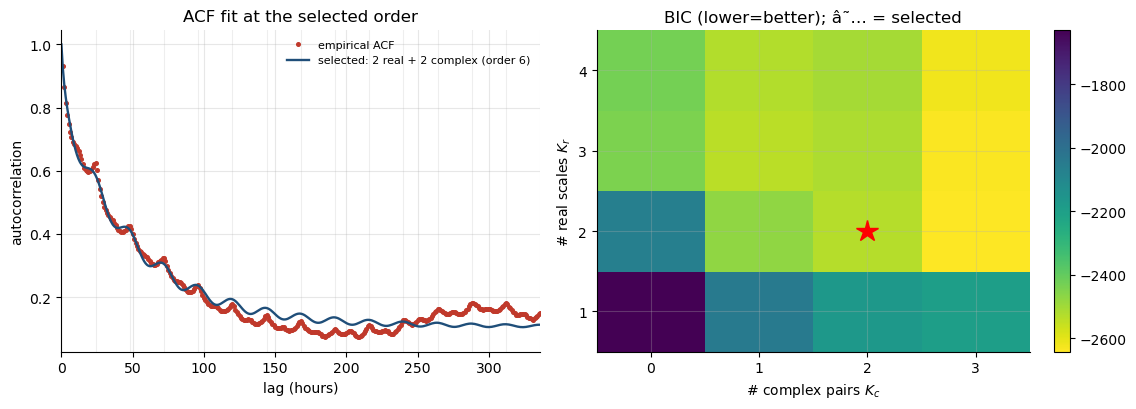

In [47]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(11.5,4.2)); kk=np.arange(0,721)
ax1.plot(np.arange(1,337),[acf(k) for k in range(1,337)],'o',ms=2.6,color='#c0392b',label='empirical ACF')
ax1.plot(kk,rho_model(sol.x,kk,Kr,Kc),'-',lw=1.7,color='#1f4e79',label=f'selected: {Kr} real + {Kc} complex (order {Kr+2*Kc})')
for d in range(24,337,24): ax1.axvline(d,color='#eee',lw=0.8,zorder=0)
ax1.set_xlim(0,336); ax1.set_xlabel('lag (hours)'); ax1.set_ylabel('autocorrelation')
ax1.set_title('ACF fit at the selected order'); ax1.legend(frameon=False,fontsize=8)
piv=tab.pivot(index='Kr',columns='Kc',values='bic')
im=ax2.imshow(piv.values,origin='lower',aspect='auto',cmap='viridis_r')
ax2.set_xticks(range(piv.shape[1])); ax2.set_xticklabels(piv.columns); ax2.set_yticks(range(piv.shape[0])); ax2.set_yticklabels(piv.index)
ax2.set_xlabel('# complex pairs $K_c$'); ax2.set_ylabel('# real scales $K_r$'); ax2.set_title('BIC (lower=better); â˜… = selected')
ax2.plot(list(piv.columns).index(Kc),list(piv.index).index(Kr),'*',color='red',ms=16)
fig.colorbar(im,ax=ax2,fraction=0.046); fig.tight_layout()
fig.savefig(FIG/'multiscale_carma_selection.pdf',bbox_inches='tight'); plt.show()


In [36]:
summary.to_csv(OUT/'price_multiscale_carma_selected_components.csv',index=False)
tab.to_csv(OUT/'price_multiscale_carma_selection_grid.csv',index=False)
payload=dict(selected=dict(Kr=Kr,Kc=Kc,order=Kr+2*Kc),
  roots=[[float(r.real),float(r.imag)] for r in roots], ar_coefficients=[float(x) for x in np.asarray(ar,float)],
  metrics=metrics(sol,Kr,Kc), base_load_oscillatory_var_share=float((tot-realtot)/tot))
(OUT/'price_multiscale_carma_selected.json').write_text(json.dumps(payload,indent=2))
print('saved:',OUT/'price_multiscale_carma_selected_components.csv')
print('saved:',OUT/'price_multiscale_carma_selection_grid.csv')
print('saved:',OUT/'price_multiscale_carma_selected.json')


saved: c:\Users\gabri\Documents\quant-projects\FR_carma_quanto\data\kalman\price_multiscale_carma_selected_components.csv
saved: c:\Users\gabri\Documents\quant-projects\FR_carma_quanto\data\kalman\price_multiscale_carma_selection_grid.csv
saved: c:\Users\gabri\Documents\quant-projects\FR_carma_quanto\data\kalman\price_multiscale_carma_selected.json


## 6. State-space representation: spectral factorisation of b

The multiscale ACF model (Section 3) determines the spectral density
$S_Y(\omega)=v_0\,N(\omega)/|a(i\omega)|^2$ analytically.
Writing $N(\omega)=\sigma^2|b(i\omega)|^2$, the **minimum-phase spectral factor** $b$ gives the
MA polynomial of the CARMA(9,8) state-space representation
$$\mathrm{d}X=AX\,\mathrm{d}t+e_p\sigma\,\mathrm{d}L(t),\quad Y=b^\top X,$$
that exactly reproduces the multiscale ACF. This $(b,\sigma)$ is the initial point for the
Kalman quasi-MLE in notebook 14.

**Algorithm.**
Since $N$ is even, $N(\omega)=P(\omega^2)$ for a degree-$(p{-}1)=8$ polynomial $P$.
(1) Build $P(u)$ analytically from eigenvalues and shares (Section 3 outputs).
(2) Find the 8 roots $u_k$ of $P$.
(3) For each $u_k$ take $z_k=i\sqrt{u_k}$ or $-i\sqrt{u_k}$ with $\mathrm{Re}(z_k)<0$.
(4) $b(z)=\prod(z-z_k)$ normalised to $b(0)=1$; $\sigma^2=v_0/(b^\top P_{\rm norm}b)$.

This section loads from saved files and runs independently of Sections 1–5.

In [37]:
# Section 6: independent — loads from saved files, does not require re-running Sections 1–5
import json, numpy as np, pandas as pd
from pathlib import Path
from scipy.linalg import expm, solve_continuous_lyapunov
import matplotlib.pyplot as plt

_CODE=Path.cwd().parent
_DATA=_CODE/'data'; _OUT=_DATA/'kalman'; _FIG=_CODE/'notebooks'/'figures'

# Empirical ACF target (same lags and weights as Section 2)
pr6=pd.read_csv(_DATA/'seasonality'/'french_panel.csv',index_col=0)['log_price_resid'].to_numpy(float)
pr6=pr6[np.isfinite(pr6)]; pr6-=pr6.mean(); N6=len(pr6); v06=float(pr6@pr6/N6)
def acf6(k): k=int(k); return 1.0 if k==0 else float(pr6[:-k]@pr6[k:]/((N6-k)*v06))
lags6=np.concatenate([np.arange(1,337),np.array([384,432,504,600,720,960,1200,1440,1800,2160,2520])])
rho_emp6=np.array([acf6(k) for k in lags6])
wts6=1/np.sqrt(lags6.astype(float)); wts6[lags6<=72]*=2; wts6[lags6>=168]*=2
for a in [1,6,12,18,24,30,48,72,96,120,144,168,336,720,1440,2160,2520]: wts6[lags6==a]*=8
sw6=np.sqrt(wts6/wts6.mean())

# Load multiscale model (Section 3 outputs)
ms6=json.loads((_OUT/'price_multiscale_carma_selected.json').read_text())
comp6=pd.read_csv(_OUT/'price_multiscale_carma_selected_components.csv')
ar6=np.array(ms6['ar_coefficients']); p6=len(ar6)

# Reconstruct κ, ω, shares from components CSV
kap6=np.array([np.log(2)/(r['half_life_d']*24) for _,r in comp6.iterrows()])
sh6 =np.array([r['share']                        for _,r in comp6.iterrows()])
oms6=np.array([0.0 if r['kind']=='real' else 2*np.pi/r['period_h'] for _,r in comp6.iterrows()])
is_r=(comp6['kind']=='real').values
kap6_r,sh6_r=kap6[is_r],sh6[is_r]
kap6_c,sh6_c,om6_c=kap6[~is_r],sh6[~is_r],oms6[~is_r]
Kr6,Kc6=int(is_r.sum()),int((~is_r).sum())
print(f'p={p6}, Kr={Kr6}, Kc={Kc6}, Σw={sh6.sum():.6f}, v0={v06:.4e}')

# Companion matrix A and stationary covariance P_norm (Lyapunov, σ=1)
A6=np.zeros((p6,p6))
for i in range(p6-1): A6[i,i+1]=1.0
A6[-1,:]=-ar6[::-1]
ep6=np.zeros(p6); ep6[-1]=1.0
P6=solve_continuous_lyapunov(A6,-np.outer(ep6,ep6))

# Multiscale ACF for comparison
def rho6_ms(h):
    h=np.asarray(h,float); out=np.zeros_like(h)
    for k,s in zip(kap6_r,sh6_r): out+=s*np.exp(-k*h)
    for k,o,s in zip(kap6_c,om6_c,sh6_c): out+=s*np.exp(-k*h)*np.cos(o*h)
    return out

# ── Build P(u) of degree p−1=8  [N(ω)=P(ω²)] ────────────────────────────
# Factors in u=ω²:  real: u+κ²;  oscillatory: u²+2(κ²−ω²)u+(κ²+ω²)²
def fp_r(k):    return np.array([1., k**2])
def fp_c(k,o):  return np.array([1., 2*(k**2-o**2), (k**2+o**2)**2])
fr=[fp_r(k) for k in kap6_r]; fc=[fp_c(k,o) for k,o in zip(kap6_c,om6_c)]

P_u=np.zeros(p6)   # accumulator, degree p−1=8 (p coefficients)
for i in range(Kr6):
    t=np.array([2*kap6_r[i]*sh6_r[i]*v06])
    for i2 in range(Kr6):
        if i2!=i: t=np.polymul(t,fr[i2])
    for j  in range(Kc6): t=np.polymul(t,fc[j])
    P_u=np.polyadd(P_u,t)
for j in range(Kc6):
    t=np.polymul(np.array([2*kap6_c[j]*sh6_c[j]*v06]),
                 np.array([1.,kap6_c[j]**2+om6_c[j]**2]))   # κⱼ²+ωⱼ²+u
    for i  in range(Kr6): t=np.polymul(t,fr[i])
    for j2 in range(Kc6):
        if j2!=j: t=np.polymul(t,fc[j2])
    P_u=np.polyadd(P_u,t)

print(f'P(u) degree={len(P_u)-1}  leading={P_u[0]:.4e}  '
      f'(expected 2v0·Σκw={2*v06*float(kap6@sh6):.4e})')

# ── Spectral factorisation: roots of b(z) ────────────────────────────────
# Each root u_k of P gives z=±i√u_k; minimum-phase → Re(z)<0
u_roots=np.roots(P_u)
b_roots=np.array([1j*np.sqrt(uk) if np.real(1j*np.sqrt(uk))<np.real(-1j*np.sqrt(uk))
                  else -1j*np.sqrt(uk) for uk in u_roots])
print(f'All b roots Re<0: {np.all(np.real(b_roots)<0)}  |  '
      f'max Re(root)={np.max(np.real(b_roots)):.2e}')

b_poly=np.poly(b_roots)              # monic polynomial, descending powers
b_asc =np.real(b_poly[::-1])        # ascending powers, real part
b6_vec=b_asc/b_asc[0]               # normalise b(0)=1
Pb6=P6@b6_vec; var06=float(b6_vec@Pb6)
sig6=float(np.sqrt(v06/var06))
print(f'\nb = {np.array2string(b6_vec,precision=4,separator=", ")}')
print(f'sigma = {sig6:.4e}  |  σ²·b^T·P_norm·b = {sig6**2*var06:.4e}  (v0={v06:.4e})')

p=6, Kr=2, Kc=2, Σw=1.000000, v0=7.9970e-04
P(u) degree=5  leading=1.4598e-04  (expected 2v0·Σκw=1.4598e-04)
All b roots Re<0: True  |  max Re(root)=-6.22e-04

b = [1.0000e+00, 1.6138e+03, 1.1187e+04, 4.2505e+04, 1.5709e+05, 1.9463e+05]
sigma = 6.2080e-08  |  σ²·b^T·P_norm·b = 7.9970e-04  (v0=7.9970e-04)


In [38]:
eAh6=np.stack([expm(A6*float(h)) for h in lags6])   # (n_lags,p,p) — ~0.5 s
rho6_sf=(eAh6@Pb6)@b6_vec/var06
rho6_ms_v=rho6_ms(lags6)
wssr6_sf=float(np.sum((sw6*(rho6_sf-rho_emp6))**2)); rmse6_sf=float(np.sqrt(np.mean((rho6_sf-rho_emp6)**2)))
wssr6_ms=float(np.sum((sw6*(rho6_ms_v-rho_emp6))**2)); rmse6_ms=float(np.sqrt(np.mean((rho6_ms_v-rho_emp6)**2)))
print('=== ACF fit (same weights as Section 3) ===')
print(f'  Multiscale model       RMSE={rmse6_ms:.6f}  WSSR={wssr6_ms:.4f}')
print(f'  CARMA(9,8) spectral b  RMSE={rmse6_sf:.6f}  WSSR={wssr6_sf:.4f}')
print(f'  ΔRMSE = {rmse6_sf-rmse6_ms:.2e}  (should be ≈0 if factorisation is exact)')
diag6=[1,6,12,18,24,30,48,72,96,120,144,168,336,720,1440,2160]
eAh6d=np.stack([expm(A6*float(h)) for h in diag6])
cmp6=pd.DataFrame({'lag_h':diag6,
    'empirical':[acf6(k) for k in diag6],
    'multiscale':rho6_ms(np.array(diag6,float)),
    'CARMA(9,8) sf-b':(eAh6d@Pb6)@b6_vec/var06})
cmp6['err_sf']=cmp6['CARMA(9,8) sf-b']-cmp6['empirical']
display(cmp6.style.format({c:'{:.4f}' for c in cmp6.columns[1:]}).hide(axis='index'))

=== ACF fit (same weights as Section 3) ===
  Multiscale model       RMSE=0.031224  WSSR=0.2027
  CARMA(9,8) spectral b  RMSE=0.031224  WSSR=0.2027
  ΔRMSE = 4.43e-12  (should be ≈0 if factorisation is exact)


lag_h,empirical,multiscale,"CARMA(9,8) sf-b",err_sf
1,0.9328,0.9253,0.9253,-0.0076
6,0.7240,0.7475,0.7475,0.0235
12,0.6620,0.6372,0.6372,-0.0248
18,0.5985,0.6092,0.6092,0.0107
24,0.6241,0.5853,0.5853,-0.0387
30,0.4860,0.5034,0.5034,0.0174
48,0.4264,0.4132,0.4132,-0.0133
72,0.3243,0.3049,0.3049,-0.0193
96,0.2375,0.2366,0.2366,-0.0009
120,0.1774,0.1933,0.1933,0.0159


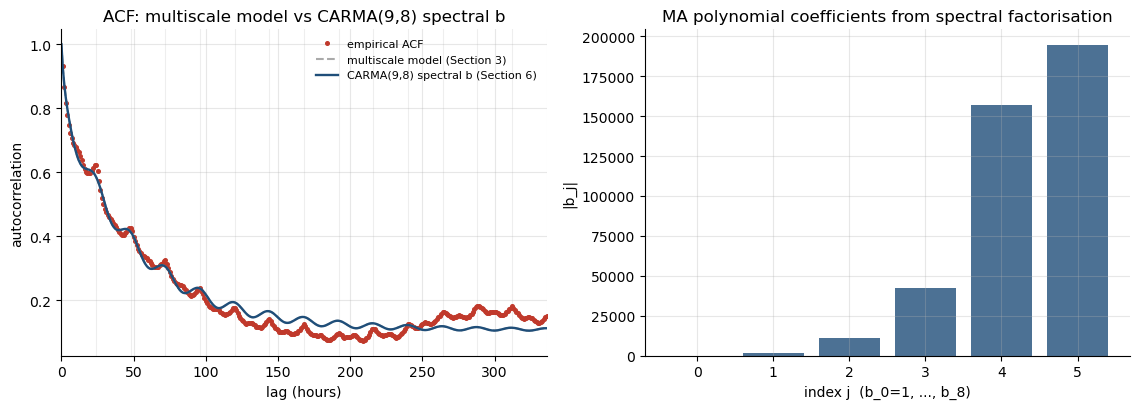

In [39]:
kk6=np.arange(0,721)
eAh6p=np.stack([expm(A6*float(h)) for h in kk6])
rho6p_sf=(eAh6p@Pb6)@b6_vec/var06
rho6p_ms=rho6_ms(kk6.astype(float))

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(11.5,4.2))
ax1.plot(np.arange(1,337),[acf6(k) for k in range(1,337)],'o',ms=2.6,color='#c0392b',label='empirical ACF')
ax1.plot(kk6,rho6p_ms,'--',lw=1.5,color='#aaa',label='multiscale model (Section 3)')
ax1.plot(kk6,rho6p_sf,'-',lw=1.7,color='#1f4e79',label='CARMA(9,8) spectral b (Section 6)')
for d in range(24,337,24): ax1.axvline(d,color='#eee',lw=0.8,zorder=0)
ax1.set_xlim(0,336); ax1.set_xlabel('lag (hours)'); ax1.set_ylabel('autocorrelation')
ax1.set_title('ACF: multiscale model vs CARMA(9,8) spectral b'); ax1.legend(frameon=False,fontsize=8)
ax2.bar(range(p6),np.abs(b6_vec),color='#1f4e79',alpha=0.8); ax2.set_xticks(range(p6))
ax2.set_xlabel('index j  (b_0=1, ..., b_8)'); ax2.set_ylabel('|b_j|')
ax2.set_title('MA polynomial coefficients from spectral factorisation')
fig.tight_layout()
fig.savefig(_FIG/'carma_spectral_b.pdf',bbox_inches='tight'); plt.show()

In [40]:
(_OUT/'price_carma_b_init.json').write_text(json.dumps(dict(
    b_coefficients=b6_vec.tolist(), sigma=float(sig6),
    AR_order=int(p6), MA_order=int(p6-1),
    acf_rmse_spectral=float(rmse6_sf), acf_rmse_multiscale=float(rmse6_ms),
    note='Spectral factorisation of b from multiscale ACF model. Init for Kalman MLE (nb03).'),
    indent=2))
print('saved:', _OUT/'price_carma_b_init.json')
print(f'\n=== Init for Kalman MLE (nb03): p={p6}, q={p6-1}, sigma={sig6:.4e} ===')
print(f'  b = {np.array2string(b6_vec,precision=4,separator=", ")}')
print(f'  ACF RMSE: spectral b = {rmse6_sf:.6f}  |  multiscale = {rmse6_ms:.6f}')

saved: c:\Users\gabri\Documents\quant-projects\FR_carma_quanto\data\kalman\price_carma_b_init.json

=== Init for Kalman MLE (nb03): p=6, q=5, sigma=6.2080e-08 ===
  b = [1.0000e+00, 1.6138e+03, 1.1187e+04, 4.2505e+04, 1.5709e+05, 1.9463e+05]
  ACF RMSE: spectral b = 0.031224  |  multiscale = 0.031224


RMSE  — MLE b: 0.064810  |  spectral b: 0.033584
WSSR  — MLE b: 1.4741  |  spectral b: 0.5708


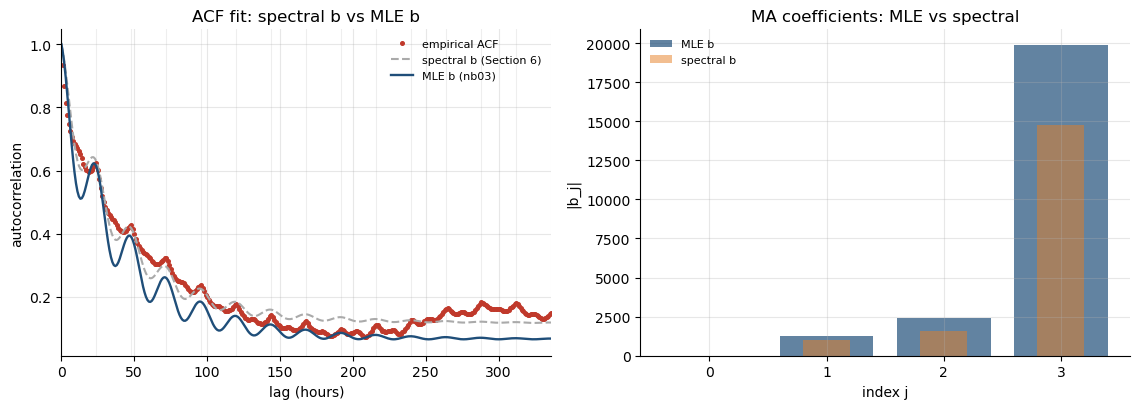

In [53]:
# Diagnostic: ACF fit with MLE b and sigma from nb03
import json, numpy as np, pandas as pd
from pathlib import Path
from scipy.linalg import expm, solve_continuous_lyapunov
import matplotlib.pyplot as plt

_CODE = Path.cwd().parent
_DATA = _CODE/'data'; _OUT = _DATA/'kalman'; _FIG = _CODE/'notebooks'/'figures'

# Load data and empirical ACF (same as Section 6)
pr6 = pd.read_csv(_DATA/'seasonality'/'french_panel.csv', index_col=0)['log_price_resid'].to_numpy(float)
pr6 = pr6[np.isfinite(pr6)]; pr6 -= pr6.mean(); N6 = len(pr6); v06 = float(pr6@pr6/N6)
def acf6(k): k=int(k); return 1.0 if k==0 else float(pr6[:-k]@pr6[k:]/((N6-k)*v06))
lags6 = np.concatenate([np.arange(1,337), np.array([384,432,504,600,720,960,1200,1440,1800,2160,2520])])
rho_emp6 = np.array([acf6(k) for k in lags6])
wts6 = 1/np.sqrt(lags6.astype(float)); wts6[lags6<=72]*=2; wts6[lags6>=168]*=2
for a in [1,6,12,18,24,30,48,72,96,120,144,168,336,720,1440,2160,2520]: wts6[lags6==a]*=8
sw6 = np.sqrt(wts6/wts6.mean())

# Load MLE result (nb03) and multiscale AR
mle  = json.loads((_OUT/'price_carma_mle_penalized_result.json').read_text())
ms6  = json.loads((_OUT/'price_multiscale_carma_selected.json').read_text())
ar6  = np.array(ms6['ar_coefficients']); p6 = len(ar6)
b_mle = np.array(mle['b_coefficients'])
sig_mle = float(mle['sigma'])

# Companion A and Lyapunov P_norm
A6 = np.zeros((p6,p6))
for i in range(p6-1): A6[i,i+1] = 1.0
A6[-1,:] = -ar6[::-1]
ep6 = np.zeros(p6); ep6[-1] = 1.0
P6 = solve_continuous_lyapunov(A6, -np.outer(ep6,ep6))

# ACF from MLE b
eAh6 = np.stack([expm(A6*float(h)) for h in lags6])
Pb_mle = P6@b_mle; var0_mle = float(b_mle@Pb_mle)
rho_mle = (eAh6@Pb_mle)@b_mle / var0_mle

# ACF from spectral b (Section 6 reference)
b_sf = json.loads((_OUT/'price_carma_b_init.json').read_text())
b_sf_vec = np.array(b_sf['b_coefficients'])
Pb_sf = P6@b_sf_vec; var0_sf = float(b_sf_vec@Pb_sf)
eAh6_all = np.stack([expm(A6*float(h)) for h in lags6])
rho_sf = (eAh6_all@Pb_sf)@b_sf_vec / var0_sf

# Metrics
rmse_mle = float(np.sqrt(np.mean((rho_mle - rho_emp6)**2)))
rmse_sf  = float(np.sqrt(np.mean((rho_sf  - rho_emp6)**2)))
wssr_mle = float(np.sum((sw6*(rho_mle - rho_emp6))**2))
wssr_sf  = float(np.sum((sw6*(rho_sf  - rho_emp6))**2))
print(f'RMSE  — MLE b: {rmse_mle:.6f}  |  spectral b: {rmse_sf:.6f}')
print(f'WSSR  — MLE b: {wssr_mle:.4f}  |  spectral b: {wssr_sf:.4f}')

# Plot
kk6 = np.arange(0,721)
eAh6p = np.stack([expm(A6*float(h)) for h in kk6])
rho_mle_p = (eAh6p@Pb_mle)@b_mle / var0_mle
rho_sf_p  = (eAh6p@Pb_sf)@b_sf_vec / var0_sf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax1.plot(np.arange(1,337), [acf6(k) for k in range(1,337)], 'o', ms=2.6, color='#c0392b', label='empirical ACF')
ax1.plot(kk6, rho_sf_p,  '--', lw=1.5, color='#aaa',    label='spectral b (Section 6)')
ax1.plot(kk6, rho_mle_p, '-',  lw=1.7, color='#1f4e79', label='MLE b (nb03)')
for d in range(24,337,24): ax1.axvline(d, color='#eee', lw=0.8, zorder=0)
ax1.set_xlim(0,336); ax1.set_xlabel('lag (hours)'); ax1.set_ylabel('autocorrelation')
ax1.set_title('ACF fit: spectral b vs MLE b'); ax1.legend(frameon=False, fontsize=8)

ax2.bar(range(p6), np.abs(b_mle),    color='#1f4e79', alpha=0.7, label='MLE b')
ax2.bar(range(p6), np.abs(b_sf_vec), color='#e67e22', alpha=0.5, label='spectral b', width=0.4)
ax2.set_xticks(range(p6)); ax2.set_xlabel('index j'); ax2.set_ylabel('|b_j|')
ax2.set_title('MA coefficients: MLE vs spectral'); ax2.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(_FIG/'carma_mle_acf_diagnostic.pdf', bbox_inches='tight'); plt.show()

kind,half_life_d,period_h,share
real,1.18,inf,0.769
osc,2.00,24.0,0.103
real,118.85,inf,0.128


RMSE=0.033589  WSSR=0.5708  (CARMA order 4)


lag_h,empirical,model,err
1,0.9328,0.9765,+0.0437
6,0.7240,0.7921,+0.0681
12,0.6620,0.6149,-0.0471
18,0.5985,0.6232,+0.0247
24,0.6241,0.6284,+0.0044
30,0.4860,0.4971,+0.0110
48,0.4264,0.4166,-0.0099
72,0.3243,0.2950,-0.0292
96,0.2375,0.2247,-0.0128
120,0.1774,0.1837,+0.0063


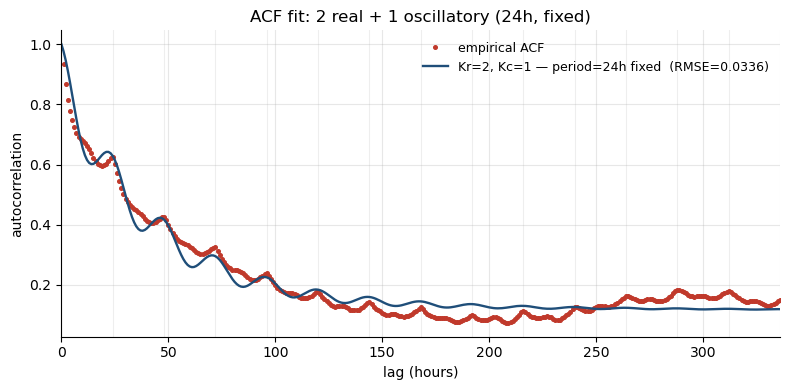

In [50]:
# ── Kr=2, Kc=1 avec période 24h fixée ─────────────────────────────
Kr, Kc = 2, 1
m = Kr + Kc          # 3 composantes au total
OM24 = 2*np.pi/24.0  # fréquence fixe

def rho_24(theta, k):
    """theta = [log_hl_0, log_hl_1, log_hl_2,  s_0, s_1, s_2]"""
    kap = np.log(2) / np.exp(theta[:m])
    sh  = softmax(theta[m:2*m])
    h   = np.asarray(k, float)
    out = sh[0]*np.exp(-kap[0]*h) + sh[1]*np.exp(-kap[1]*h)
    out += sh[2]*np.exp(-kap[2]*h)*np.cos(OM24*h)
    return out

# bornes : osc → t½ ≥ 2 jours (log(48h)), réels libres
lb_hl = [np.log(0.3), np.log(0.3), np.log(48.0)]
ub_hl = [np.log(8760)] * 3
lb = lb_hl + [-9]*3
ub = ub_hl + [ 9]*3

x0  = np.r_[np.log([36., 2000., 96.]), [0.]*3]
rng = np.random.default_rng(42)
best = None
for s in range(16):
    xs = x0.copy()
    if s > 0:
        xs[:m]   += rng.normal(0, 0.4, m)
        xs[m:2*m] += rng.normal(0, 1.0, m)
    xs = np.clip(xs, lb, ub)
    r  = least_squares(lambda t: sw*(rho_24(t, lags)-rho_emp),
                       xs, bounds=(lb, ub), max_nfev=5000)
    if best is None or r.cost < best.cost:
        best = r

kap_b = np.log(2) / np.exp(best.x[:m])
sh_b  = softmax(best.x[m:2*m])

# ── tableau des composantes ────────────────────────────────────────
rows = []
for i in range(Kr):
    rows.append(dict(kind='real', half_life_d=np.log(2)/kap_b[i]/24,
                     period_h=np.inf, share=sh_b[i]))
rows.append(dict(kind='osc',  half_life_d=np.log(2)/kap_b[Kr]/24,
                 period_h=24.0, share=sh_b[Kr]))
summary_24 = pd.DataFrame(rows).sort_values('half_life_d').reset_index(drop=True)
display(summary_24.style.format({'half_life_d':'{:.2f}','period_h':'{:.1f}','share':'{:.3f}'}).hide(axis='index'))

rmse_24 = float(np.sqrt(np.mean((rho_24(best.x, lags)-rho_emp)**2)))
wssr_24 = float(np.sum((sw*(rho_24(best.x, lags)-rho_emp))**2))
print(f'RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}  (CARMA order {Kr+2*Kc})')

# ── tableau lag diagnostique ───────────────────────────────────────
diag = [1,6,12,18,24,30,48,72,96,120,144,168,336,720,1440,2160]
cmp = pd.DataFrame({
    'lag_h'    : diag,
    'empirical': [acf(k) for k in diag],
    'model'    : rho_24(best.x, np.array(diag, float))
})
cmp['err'] = cmp['model'] - cmp['empirical']
display(cmp.style.format({'empirical':'{:.4f}','model':'{:.4f}','err':'{:+.4f}'}).hide(axis='index'))

# ── plot ACF ───────────────────────────────────────────────────────
kk = np.arange(0, 721)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1,337), [acf(k) for k in range(1,337)],
        'o', ms=2.6, color='#c0392b', label='empirical ACF')
ax.plot(kk, rho_24(best.x, kk), '-', lw=1.7, color='#1f4e79',
        label=f'Kr=2, Kc=1 — period=24h fixed  (RMSE={rmse_24:.4f})')
for d in range(24, 337, 24):
    ax.axvline(d, color='#eee', lw=0.8, zorder=0)
ax.set_xlim(0, 336); ax.set_xlabel('lag (hours)'); ax.set_ylabel('autocorrelation')
ax.set_title('ACF fit: 2 real + 1 oscillatory (24h, fixed)')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()


P(u) degree=3  leading=3.2382e-05  (expected 2v0·Σκw=3.2382e-05)
All b roots Re<0: True  |  max Re=-1.02e-03
b = [1.0000e+00, 9.7753e+02, 1.5524e+03, 1.4744e+04]
b^T·P_norm·b = 5.3683e+09  (v0=7.9970e-04)

=== ACF verification ===
  Multiscale model  RMSE=0.033909  WSSR=0.5668
  Spectral b        RMSE=0.033584  WSSR=0.5708
  ΔRMSE = -3.25e-04  (should be ≈0)


lag_h,empirical,multiscale,"CARMA(4,3) sf-b",err_sf
1,0.9328,0.9764,0.9765,0.0437
6,0.7240,0.7899,0.7922,0.0682
12,0.6620,0.6152,0.6151,-0.0469
18,0.5985,0.6294,0.6235,0.0250
24,0.6241,0.6284,0.6287,0.0047
30,0.4860,0.4891,0.4974,0.0114
48,0.4264,0.4159,0.4170,-0.0095
72,0.3243,0.2938,0.2954,-0.0289
96,0.2375,0.2230,0.2251,-0.0125
120,0.1774,0.1817,0.1840,0.0066


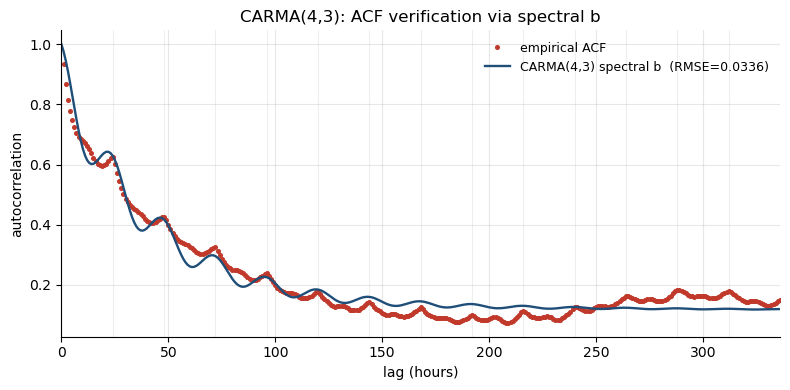

saved: price_multiscale_carma_selected.json
saved: price_carma_b_init.json

=== Init for nb03: p=4, q=3 ===
  b = [1.0000e+00, 9.7753e+02, 1.5524e+03, 1.4744e+04]


In [55]:
# ── Spectral factorisation CARMA(4,3) + sauvegarde ────────────────
from scipy.linalg import expm, solve_continuous_lyapunov

kap_r = kap_b[:Kr]; sh_r = sh_b[:Kr]
kap_c = kap_b[Kr:]; sh_c = sh_b[Kr:]
om_c  = np.array([2*np.pi/24.0])
p     = Kr + 2*Kc  # = 4

roots_ar = ([complex(-kap_r[i], 0) for i in range(Kr)] +
            [complex(-kap_c[0],  om_c[0]),
             complex(-kap_c[0], -om_c[0])])
ar = np.real(np.poly(roots_ar)[1:])

A = np.zeros((p, p))
for i in range(p-1): A[i, i+1] = 1.0
A[-1, :] = -ar[::-1]
ep = np.zeros(p); ep[-1] = 1.0
P_norm = solve_continuous_lyapunov(A, -np.outer(ep, ep))

fp_r2 = lambda k:    np.array([1., k**2])
fp_c2 = lambda k, o: np.array([1., 2*(k**2-o**2), (k**2+o**2)**2])
fr2 = [fp_r2(k) for k in kap_r]
fc2 = [fp_c2(k, o) for k, o in zip(kap_c, om_c)]

P_u = np.zeros(p)
for i in range(Kr):
    t = np.array([2*kap_r[i]*sh_r[i]*v0])
    for i2 in range(Kr):
        if i2 != i: t = np.polymul(t, fr2[i2])
    for j in range(Kc): t = np.polymul(t, fc2[j])
    P_u = np.polyadd(P_u, t)
for j in range(Kc):
    t = np.polymul(np.array([2*kap_c[j]*sh_c[j]*v0]),
                   np.array([1., kap_c[j]**2 + om_c[j]**2]))
    for i in range(Kr): t = np.polymul(t, fr2[i])
    P_u = np.polyadd(P_u, t)

print(f'P(u) degree={len(P_u)-1}  leading={P_u[0]:.4e}  '
      f'(expected 2v0·Σκw={2*v0*float(np.r_[kap_r,kap_c]@sh_b):.4e})')

u_roots = np.roots(P_u)
b_roots = np.array([1j*np.sqrt(uk) if np.real(1j*np.sqrt(uk)) < np.real(-1j*np.sqrt(uk))
                    else -1j*np.sqrt(uk) for uk in u_roots])
print(f'All b roots Re<0: {np.all(np.real(b_roots)<0)}  |  max Re={np.max(np.real(b_roots)):.2e}')

b_vec = np.real(np.poly(b_roots)[::-1])
b_vec = b_vec / b_vec[0]
Pb    = P_norm @ b_vec
var0  = float(b_vec @ Pb)
print(f'b = {np.array2string(b_vec, precision=4, separator=", ")}')
print(f'b^T·P_norm·b = {var0:.4e}  (v0={v0:.4e})')

# ── Vérification ACF ──────────────────────────────────────────────
eAh  = np.stack([expm(A*float(h)) for h in lags])
rho_sf = (eAh @ Pb) @ b_vec / var0
rmse_sf = float(np.sqrt(np.mean((rho_sf - rho_emp)**2)))
wssr_sf = float(np.sum((sw*(rho_sf - rho_emp))**2))
print(f'\n=== ACF verification ===')
print(f'  Multiscale model  RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}')
print(f'  Spectral b        RMSE={rmse_sf:.6f}  WSSR={wssr_sf:.4f}')
print(f'  ΔRMSE = {rmse_sf - rmse_24:.2e}  (should be ≈0)')

diag = [1,6,12,18,24,30,48,72,96,120,144,168,336,720,1440,2160]
eAhd = np.stack([expm(A*float(h)) for h in diag])
cmp  = pd.DataFrame({'lag_h': diag,
    'empirical'       : [acf(k) for k in diag],
    'multiscale'      : rho_24(best.x, np.array(diag, float)),
    'CARMA(4,3) sf-b' : (eAhd @ Pb) @ b_vec / var0})
cmp['err_sf'] = cmp['CARMA(4,3) sf-b'] - cmp['empirical']
display(cmp.style.format({c:'{:.4f}' for c in cmp.columns[1:]}).hide(axis='index'))

kk   = np.arange(0, 721)
eAhp = np.stack([expm(A*float(h)) for h in kk])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1,337), [acf(k) for k in range(1,337)],
        'o', ms=2.6, color='#c0392b', label='empirical ACF')
ax.plot(kk, (eAhp@Pb)@b_vec/var0, '-', lw=1.7, color='#1f4e79',
        label=f'CARMA(4,3) spectral b  (RMSE={rmse_sf:.4f})')
for d in range(24, 337, 24): ax.axvline(d, color='#eee', lw=0.8, zorder=0)
ax.set_xlim(0, 336); ax.set_xlabel('lag (hours)'); ax.set_ylabel('autocorrelation')
ax.set_title('CARMA(4,3): ACF verification via spectral b')
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

# ── Sauvegarde ────────────────────────────────────────────────────
def _ser(x): return None if (isinstance(x, float) and not np.isfinite(x)) else float(x)

payload = dict(
    selected      = dict(Kr=Kr, Kc=Kc, order=p),
    roots         = [[float(r.real), float(r.imag)] for r in roots_ar],
    ar_coefficients = [float(x) for x in ar],
    b_coefficients  = b_vec.tolist(),
    metrics = dict(rmse_multiscale=float(rmse_24), wssr_multiscale=float(wssr_24),
                   rmse_spectral=float(rmse_sf),   wssr_spectral=float(wssr_sf)),
    components = [dict(kind=r['kind'], half_life_d=float(r['half_life_d']),
                       period_h=_ser(r['period_h']), share=float(r['share']))
                  for _, r in summary_24.iterrows()],
    note = 'Kr=2 Kc=1 period=24h fixed t_half_osc>=2d. CARMA(4,3). No sigma: model is dX=AX dt+ep dL(t).'
)
(OUT/'price_multiscale_carma_selected.json').write_text(json.dumps(payload, indent=2))
(OUT/'price_carma_b_init.json').write_text(json.dumps(dict(
    b_coefficients=b_vec.tolist(),
    AR_order=int(p), MA_order=int(p-1),
    acf_rmse_spectral=float(rmse_sf), acf_rmse_multiscale=float(rmse_24),
    note=f'CARMA({p},{p-1}) spectral b. Kr=2 Kc=1 period=24h fixed. No sigma.'), indent=2))
print('saved: price_multiscale_carma_selected.json')
print('saved: price_carma_b_init.json')
print(f'\n=== Init for nb03: p={p}, q={p-1} ===')
print(f'  b = {np.array2string(b_vec, precision=4, separator=", ")}')
